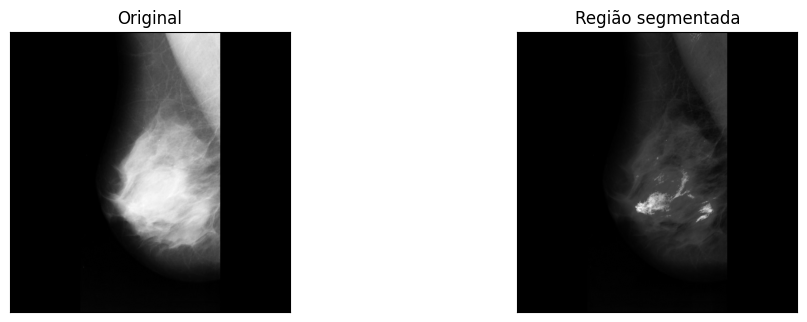

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
img=cv2.imread('mom_clahe.jpg',0)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
# Os valores clipLimit e tileGridSize são definidos pelo usuário
cl = clahe.apply(img)
#Realizando o alargamento de contraste
def pixelVal(pix, r1, s1, r2, s2):
	if (0 <= pix and pix <= r1):
		return (s1 / r1)*pix
	elif (r1 < pix and pix <= r2):
		return ((s2 - s1)/(r2 - r1)) * (pix - r1) + s1
	else:
		return ((255 - s2)/(255 - r2)) * (pix - r2) + s2

# Definindo valores de r1, r2, s1, s2
r1 = 215
s1 = 100
r2 = 300
s2 = 800
pixelVal_vec = np.vectorize(pixelVal)
contrast_stretched = pixelVal_vec(cl, r1, s1, r2, s2)

#Plotando resultados
plt.figure(figsize=(12,8))
plt.subplot (2,2,1)
plt.imshow(img,cmap=plt.cm.gray)
plt.title('Original'),plt.xticks([]), plt.yticks([])
plt.subplot (2,2,2)
plt.imshow(contrast_stretched,cmap=plt.cm.gray)
plt.title('Região segmentada'),plt.xticks([]), plt.yticks([])
plt.show()